In [41]:
import sys
import matplotlib.pyplot as plt
import pywt
import math
from matplotlib import colors
import numpy as np
from typing import Optional, Any, TypedDict, List
import pandas as pd
from pandas import DataFrame
from scipy.signal import hilbert, butter, filtfilt, remez, find_peaks, resample, resample_poly
from scipy.signal import savgol_filter, medfilt
from wulpus.helper import zip_to_dataframe, find_latest_measurement_zip, concat_dataframes, get_all_zips_from_folder, to_index_range, to_2d_nan_padded
from wulpus.plot_helpers import flatten_df_measurements, imshow_with_time, format_time_xticks, flatten_df_measurements, format_time_index_to_local

In [42]:
class PeakData(TypedDict):
    p: float
    peak_position: int
    p_wavelet: float
    peak_wvlt_position: int
    p2p: float
    p2p_wavelet: float
    peak_position_pos: int
    peak_position_neg: int
    
class Data(TypedDict):
    flattened_df: DataFrame
    y: np.ndarray
    x: List[int]
    raw_df: DataFrame
    wavelet_values: Optional[np.ndarray]
    boundaries: List[int]
    peaks: Optional[PeakData]
    ui_peaks: Optional[np.ndarray]
    

In [43]:
paths = get_all_zips_from_folder("C:\\Users\\louis\\OneDrive - UBC\\jones193@student.ubc.ca's files - DLR@UBC\\Other\\VARI-protocols\\VARI-20251216\\3_Main-Run\\Classics")
SAMPLE_CROP = 100 #  no crop e.g. 99999

df, config = zip_to_dataframe(paths[0])
if len(paths) > 1:
    print(f"Multiple ({len(paths)}) paths detected, concatenating DataFrames")
    for p in paths[1:]:
        df_new, config_new = zip_to_dataframe(p, ignore_first_frames=1)
        df = concat_dataframes([df, df_new])
        config = config_new
df.head()

Multiple (403) paths detected, concatenating DataFrames


,measurement,tx,rx,aq_number,tx_rx_id,log_version,wulpus
1766006753190310,0 8 1 209 2 980 3 166...,[0],[1],0,0,1,D
1766006753439531,0 -4 1 -87 2 -375 3 -51...,[2],[3],1,1,1,D
1766006753678644,0 -5 1 -127 2 -591 3 -88...,[4],[5],2,2,1,D
1766006753925179,0 2 1 47 2 192 3 286 4 ...,[6],[7],3,3,1,D
1766006754190490,0 -2 1 -27 2 -108 3 -19...,[0],[1],4,0,1,D


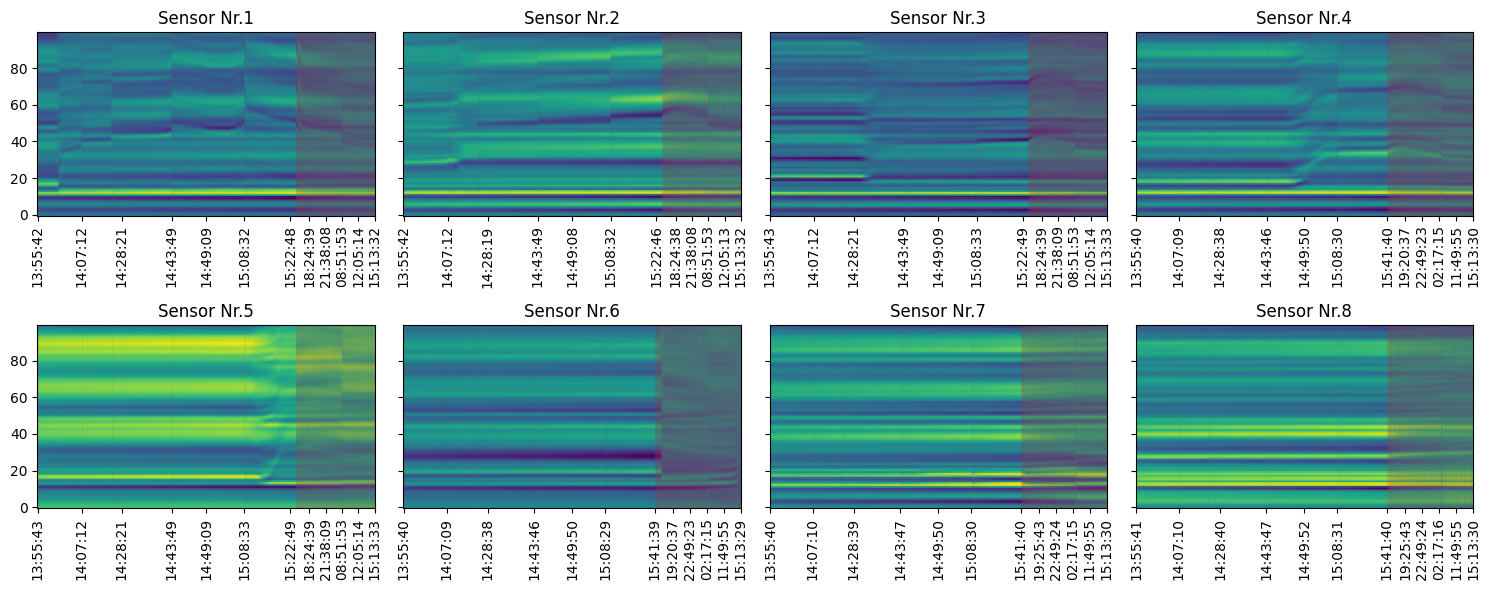

In [68]:

def gen_metrics(arr: np.ndarray, ignore_n: int):
    offset = ignore_n if arr.shape[1] > ignore_n else arr.shape[1]
    sliced = arr[:, offset:] if offset else arr
    p = np.nanmax(np.abs(sliced), axis=1)
    p2p = np.nanmax(sliced, axis=1) - np.nanmin(sliced, axis=1)
    abs_vals = np.abs(sliced)
    abs_vals[np.isnan(abs_vals)] = -np.inf
    peak_pos = np.argmax(abs_vals, axis=1) + offset
    peak_neg = np.argmin(sliced, axis=1) + offset
    return p, p2p, peak_pos, peak_neg, sliced, offset

def print_borders(sensor: Data, ax: Any):
    for bx in sensor["boundaries"]:
        ax.axvline(bx, color='red', alpha=0.1, linewidth=0.5, zorder=0)

# Order of sensors
df_sel_1 = df.loc[df["rx"].apply(lambda rx: 3 in rx) & (df["wulpus"] == "E")]
df_sel_2 = df.loc[df["rx"].apply(lambda rx: 1 in rx) & (df["wulpus"] == "E")]
df_sel_3 = df.loc[df["rx"].apply(lambda rx: 7 in rx) & (df["wulpus"] == "E")]
df_sel_4 = df.loc[df["rx"].apply(lambda rx: 3 in rx) & (df["wulpus"] == "D")]
df_sel_5 = df.loc[df["rx"].apply(lambda rx: 5 in rx) & (df["wulpus"] == "E")]
df_sel_6 = df.loc[df["rx"].apply(lambda rx: 1 in rx) & (df["wulpus"] == "D")]
df_sel_7 = df.loc[df["rx"].apply(lambda rx: 5 in rx) & (df["wulpus"] == "D")]
df_sel_8 = df.loc[df["rx"].apply(lambda rx: 7 in rx) & (df["wulpus"] == "D")]
df_sel = [df_sel_1, df_sel_2, df_sel_3, df_sel_4, df_sel_5, df_sel_6, df_sel_7, df_sel_8]
# display(df_sel.head())


data:list[Data] = [] 
for i, dataset in enumerate(df_sel):
    flattened_df, meas_cols = flatten_df_measurements(
        dataset, sample_crop=SAMPLE_CROP)
    
    # Detect time discontinuities (stitched logs) to mark boundaries in the bottom plot
    boundary_x = []
    times = pd.to_datetime(dataset.index, errors='coerce')
    if hasattr(times, 'isna') and not times.isna().all():
        dt = pd.Series(times).diff().dt.total_seconds().to_numpy()
        dt_pos = dt[np.isfinite(dt) & (dt > 0)]
        typical_dt = float(np.median(dt_pos)) if dt_pos.size else float('nan')
        if np.isfinite(typical_dt) and typical_dt > 0:
            gap_threshold = 10.0 * typical_dt
            boundary_x = np.where((dt < 0) | (dt > gap_threshold))[0].tolist()
            
    data.append(Data(
        flattened_df=flattened_df,
        y=flattened_df[meas_cols].to_numpy(dtype=float),
        x=flattened_df.index,
        raw_df = dataset,
        boundaries = boundary_x,
    ))


fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
for i, sensor in enumerate(data):
    ax = axs[i//4, i%4]
    ax.set_title(f"Sensor Nr.{i+1}")
    im = ax.imshow(sensor["y"].T, aspect='auto', cmap='viridis', origin='lower')
    print_borders(sensor, ax)
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)

# plt.colorbar(im)
plt.tight_layout()


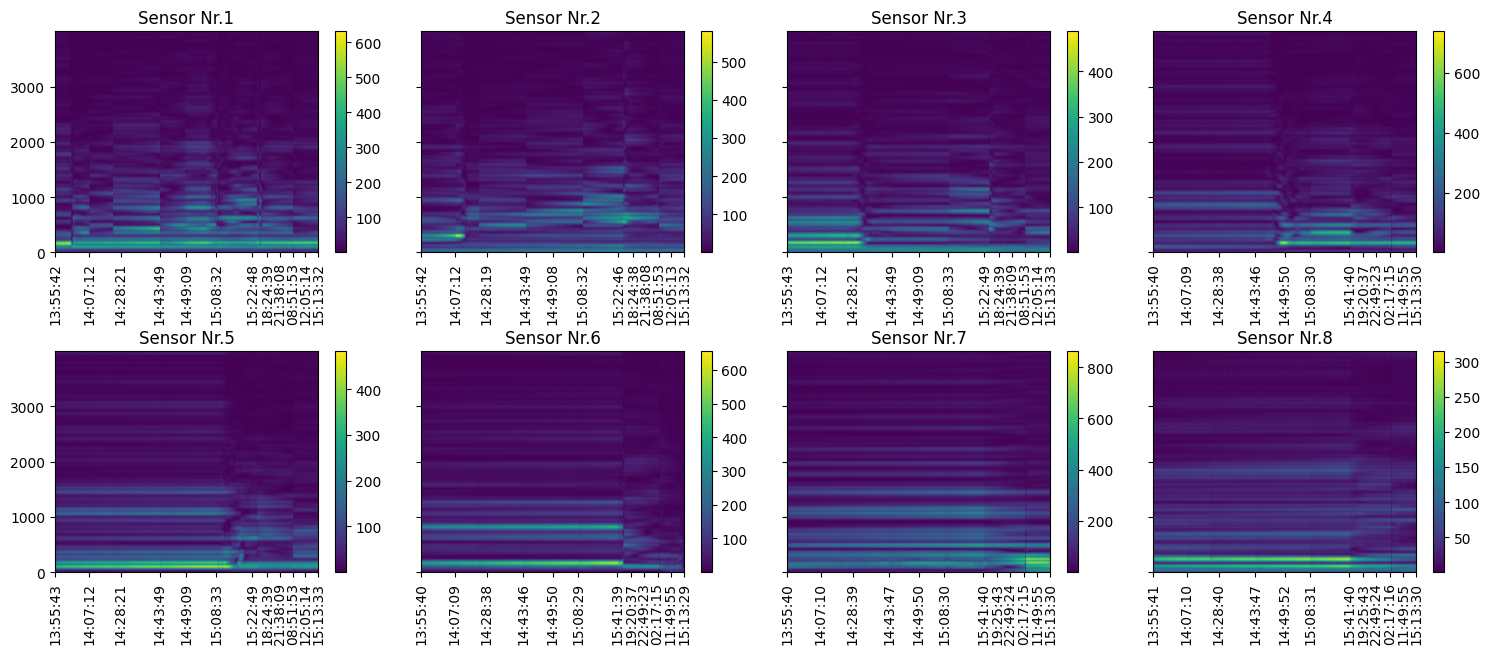

In [45]:
from wulpus.data_processing import MeasurementProcessor

fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
    
for i, sensor in enumerate(data):
    processor = MeasurementProcessor()

    # Process each measurement and collect wavelets
    wavelet_list = []
    uipeak_list = []
    for measurement in sensor["raw_df"]["measurement"]:
        res = processor.process_measurement(
            measurement={
                "data": measurement,
                "rx": [0],
                "tx": [0],
                "time": 0,
                "mesh_origin": 0,
            },
            config=config,
        )
        wavelet_list.append(np.asarray(res.wavelet).ravel())
        uipeak_list.append(np.asarray(res.peaks))

    # Stack into a 2D array. If wavelets have different lengths, pad with NaN.
    max_len = max(len(w) for w in wavelet_list)
    sensor["wavelet_values"] = np.full((len(wavelet_list), max_len), np.nan, dtype=float)
    wavelet_values = sensor["wavelet_values"]
    sensor["ui_peaks"] = to_2d_nan_padded(uipeak_list)
    for j, w in enumerate(wavelet_list):
        wavelet_values[j, : len(w)] = w

    ax = axs[i//4, i%4]
    ax.set_title(f"Sensor Nr.{i+1}")
    im = ax.imshow(wavelet_values.T, aspect='auto', cmap='viridis', origin='lower')
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
    
    plt.colorbar(im)

# Flowfront detection

In [46]:
ground_truth_us = [
        (1766008620000000, 1766008740000000),
        (1766009160000000, 1766009400000000),
        (1766010420000000, 1766010960000000),
        (1766011500000000, 1766011920000000),
        (1766012760000000, 1766013840000000),
        (0, 0),
        (0, 0),
        (0, 0),
    ]

In [65]:
def print_flowfront(ax: plt.Axes, x_loc: Optional[int], label: Optional[str] = None):
    if x_loc is not None:
        ax.axvline(x_loc, color='red', linestyle='--', linewidth=1, alpha=1)
        if label:
            ax.text(0.5, 0.5, 'matplotlib', horizontalalignment='center',
                    verticalalignment='center', label=label, rotation=90, va='center')


def get_peak_metrics(wavelet_arr: np.ndarray, raw_arr: np.ndarray, ignore_n: Optional[int] = None, wavelet_scaling_factor: int = 10) -> PeakData:
    sliced = raw_arr[:, ignore_n:]
    
    sliced_abs_wvlt = np.abs(wavelet_arr)
    sliced_abs = np.abs(sliced)
    
    p = np.nanmax(sliced_abs, axis=1)
    peak_position = np.nanargmax(sliced_abs, axis=1) + ignore_n
    
    p_wavelet = np.nanmax(sliced_abs_wvlt, axis=1)
    peak_wvlt_position = np.nanargmax(wavelet_arr, axis=1)
    
    p2p = np.nanmax(sliced, axis=1) - np.nanmin(sliced, axis=1)
    p2p_wavelet = np.nanmax(wavelet_arr, axis=1) - np.nanmin(wavelet_arr, axis=1)
    peak_position_pos = np.nanargmax(sliced, axis=1) + ignore_n
    peak_position_neg = np.nanargmin(sliced, axis=1) + ignore_n
    # neg peak positon doesn't make sense in wavelet, as ther's no information contained there
    return PeakData(p=p,
                    peak_position=peak_position,
                    p_wavelet=p_wavelet,
                    peak_wvlt_position=peak_wvlt_position,
                    p2p=p2p,
                    p2p_wavelet=p2p_wavelet,
                    peak_position_pos=peak_position_pos,
                    peak_position_neg=peak_position_neg)


def print_ground_truth(ax: plt.Axes, sensor: Data, sensor_index):
    ground_truth_idx = to_index_range(sensor["x"], ground_truth_us[sensor_index])
    if ground_truth_idx[0] and ground_truth_idx[1]:
        ax.axvspan(ground_truth_idx[0], ground_truth_idx[1],
                   color="green", alpha=0.15, label="Ground truth")
        
def create_legend(fig: plt.Figure, *axes: plt.Axes):
    all_h, all_l = [], []
    for a in axes:
        h, l = a.get_legend_handles_labels()
        all_h += h
        all_l += l
    seen = set()
    handles, labels = [], []
    for h, l in zip(all_h, all_l):
        if l and (l not in seen):
            seen.add(l)
            handles.append(h)
            labels.append(l)
    fig.legend(handles, labels, bbox_to_anchor=(0, -0), loc='upper left')
    fig.tight_layout()


### ... based on Amplitude

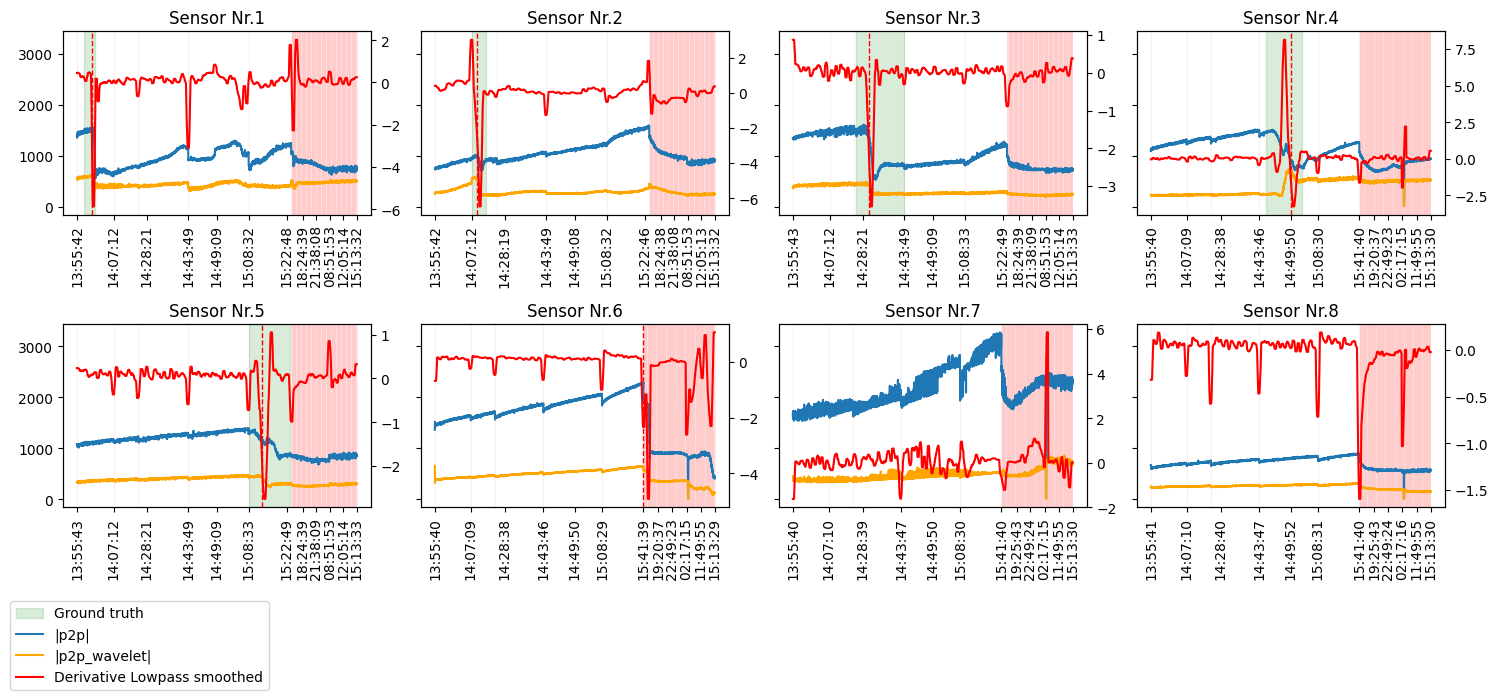

In [48]:

fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
IGNORE_FIRST_N_SAMPLES = 15
for i, sensor in enumerate(data):
    sensor["peaks"] = get_peak_metrics(sensor["wavelet_values"], sensor["y"], ignore_n=IGNORE_FIRST_N_SAMPLES)
    peaks = sensor["peaks"]
    smooth_p_wavelet = savgol_filter(peaks['p_wavelet']/10, 50, 2)

    smooth_deriv = savgol_filter(peaks['p2p_wavelet'], 50, 2, deriv=1)
    smooth_deriv_lowpass = medfilt(smooth_deriv, kernel_size=29)

    curing_index = np.where(smooth_deriv_lowpass <= -2)[0]
    curing_index = int(curing_index[0]) if curing_index.size else None

    ax = axs[i//4, i % 4]
    ax.set_title(f"Sensor Nr.{i+1}")    
    print_ground_truth(ax, sensor, i)
    print_flowfront(ax, curing_index)
    # ax.plot(peaks['p_wavelet']/10, label='|p_wavelet|')
    # ax.plot(smooth_p_wavelet, label='|p_wavelet| smoothed')
    ax.plot(peaks['p2p'], label='|p2p|')
    ax.plot(peaks['p2p_wavelet'], label='|p2p_wavelet|', color='orange')
    ax2 = ax.twinx()
    ax2.plot(smooth_deriv_lowpass,
             label='Derivative Lowpass smoothed', color='red')
    fig.tight_layout()
    print_borders(sensor, ax)
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
create_legend(fig, *fig.axes)
fig.tight_layout()

wavelet data seems to enable a clearer distinguishment of the flowfront

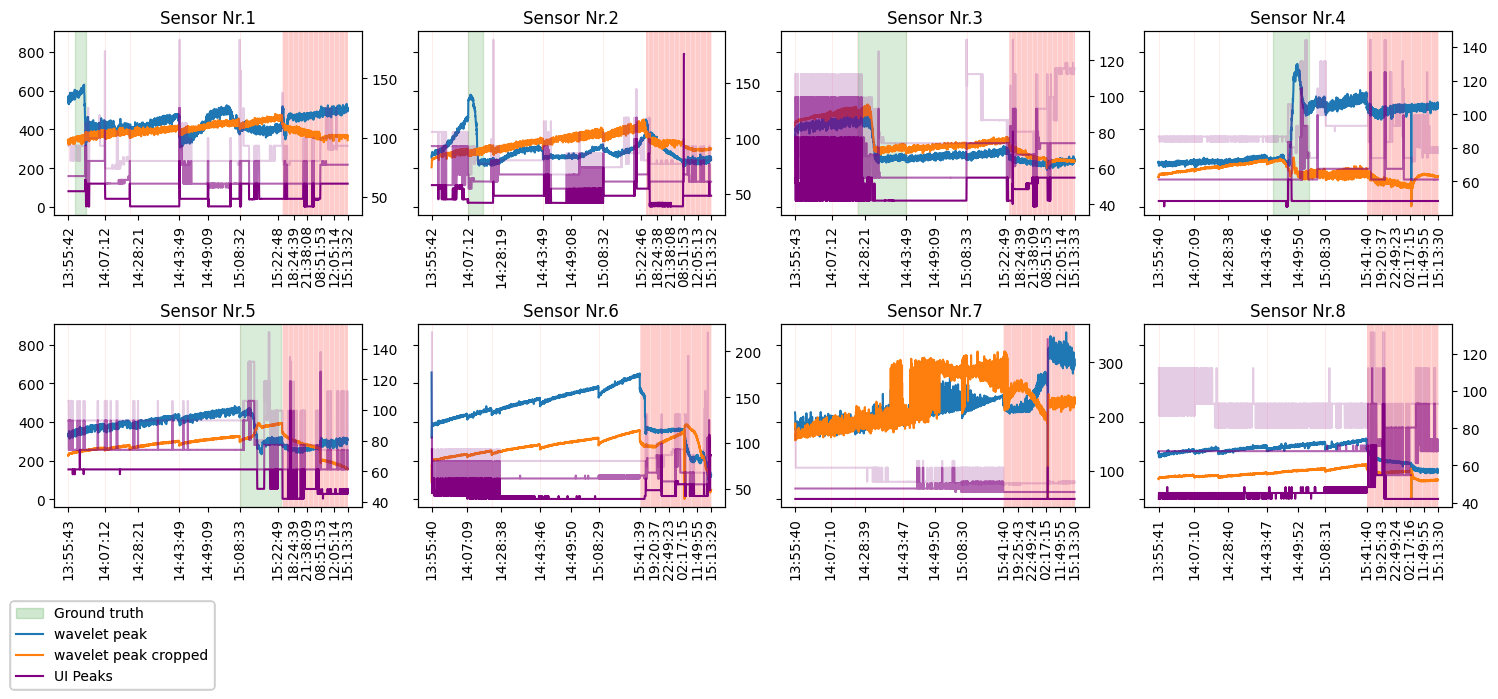

In [49]:
def limit_slew_rate(data: np.ndarray, max_change: float) -> np.ndarray:
    limited_data = np.zeros_like(data)
    limited_data[0] = 0
    for i in range(1, len(data)):
        change = data[i] - limited_data[i - 1]
        limited_change = np.clip(change, -max_change, max_change)
        limited_data[i] = limited_data[i - 1] + limited_change
    return limited_data

fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
for i, sensor in enumerate(data):      
    deriv_raw = savgol_filter(sensor['peaks']["p2p"], 20, 2, deriv=1)
    deriv_wavelet = savgol_filter(sensor['peaks']["p2p"], 20, 2, deriv=1)
    
    max_allowed_jump = 0.001 * np.var(smooth_deriv)
    deriv_slew_rate = limit_slew_rate(smooth_deriv, max_allowed_jump)

    curing_index = np.where(deriv_slew_rate <= -0.05)[0]
    curing_index = int(curing_index[0]) if curing_index.size else None


    processor = MeasurementProcessor()

    # Process each measurement and collect wavelets
    wavelet_list = []
    for measurement in sensor["raw_df"]["measurement"]:
        res = processor.process_measurement(
            measurement={
                "data": measurement[:SAMPLE_CROP],
                "rx": [0],
                "tx": [0],
                "time": 0,
                "mesh_origin": 0,
            },
            config=config,
        )
        wavelet_list.append(np.asarray(res.wavelet).ravel())
    # Stack into a 2D array. If wavelets have different lengths, pad with NaN.
    max_len = max(len(w) for w in wavelet_list)
    wavelet_values_cropped = np.full((len(wavelet_list), max_len), np.nan, dtype=float)
    for j, w in enumerate(wavelet_list):
        wavelet_values_cropped[j, : len(w)] = w
    cropped_wavelet_peaks = get_peak_metrics(wavelet_values_cropped, sensor["y"], ignore_n=IGNORE_FIRST_N_SAMPLES)


    sliced = sensor["wavelet_values"][:, IGNORE_FIRST_N_SAMPLES*10:]
    inpt = np.nanmax(sliced, axis=1) - np.nanmin(sliced, axis=1)
    smooth_deriv = savgol_filter(inpt, 50, 2, deriv=1)
    smooth_deriv_lowpass = medfilt(smooth_deriv, kernel_size=29)

    ax = axs[i//4, i % 4]
    ax.set_title(f"Sensor Nr.{i+1}")
    print_ground_truth(ax, sensor, i)
    print_borders(sensor, ax)
    ax.plot(sensor["peaks"]["p_wavelet"], label='wavelet peak', zorder=2.5)
    ax.plot(cropped_wavelet_peaks["p_wavelet"], label='wavelet peak cropped', zorder=2.5)
    ax2 = ax.twinx()
    ax2.plot(sensor["ui_peaks"][:, 0], label='UI Peaks', color='purple', alpha=1)
    ax2.plot(sensor["ui_peaks"][:, 1], color='purple', alpha=0.6)
    ax2.plot(sensor["ui_peaks"][:, 2], color='purple', alpha=0.2)

    create_legend(fig, *fig.axes)
    fig.tight_layout()
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)

### ... based on phase shift

seems less promising

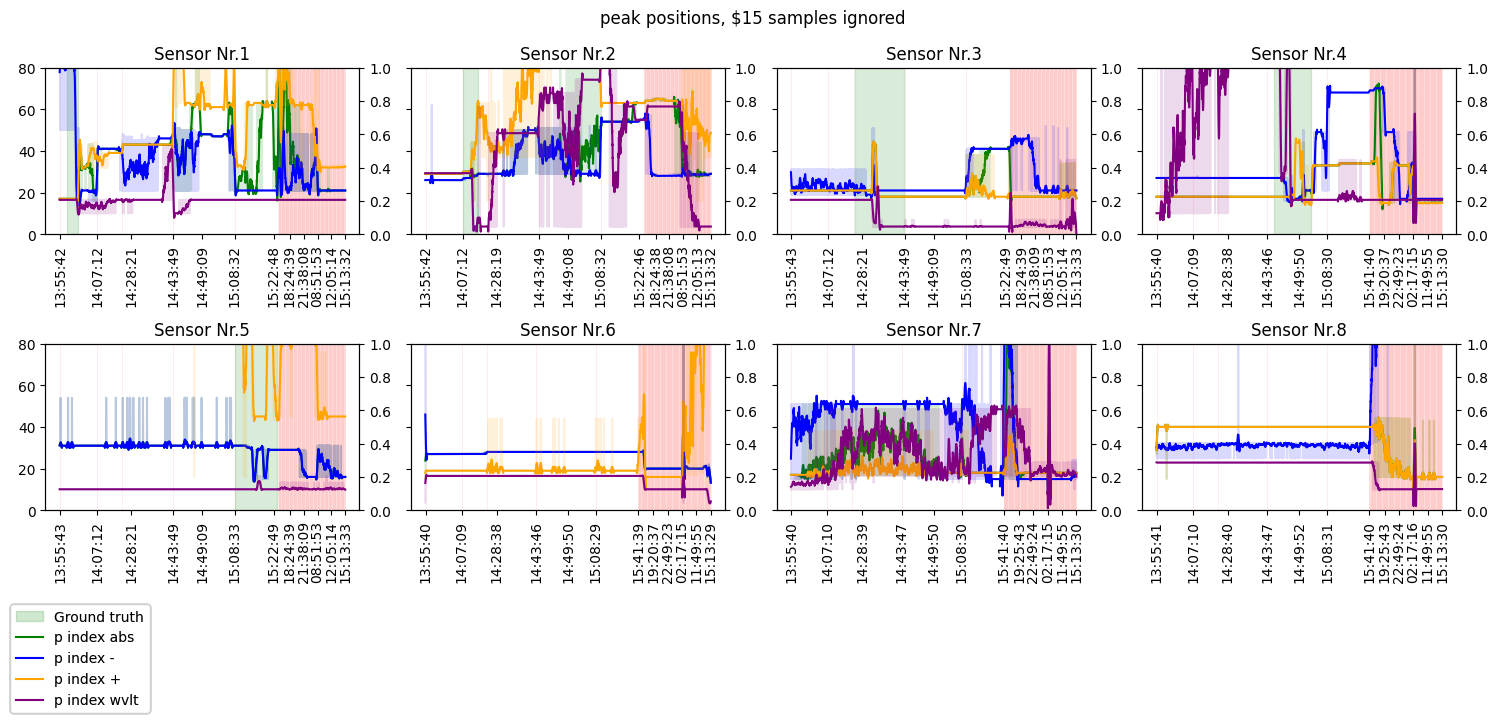

In [ ]:
def limit_slew_rate(data: np.ndarray, max_change: float) -> np.ndarray:
    limited_data = np.zeros_like(data)
    limited_data[0] = 0
    for i in range(1, len(data)):
        change = data[i] - limited_data[i - 1]
        limited_change = np.clip(change, -max_change, max_change)
        limited_data[i] = limited_data[i - 1] + limited_change
    return limited_data

fig, axs = plt.subplots(2, 4, sharey=True, figsize=(15, 6))
plt.tight_layout(h_pad=5.0)
for i, sensor in enumerate(data):   
    ax = axs[i//4, i % 4]
    ax.set_title(f"Sensor Nr.{i+1}")
    print_ground_truth(ax, sensor, i)
    print_borders(sensor, ax)
      
    ax2 = ax.twinx()  
    ax.plot(sensor['peaks']['peak_position'], color='green', alpha=0.15)
    ax.plot(savgol_filter(sensor['peaks']['peak_position'], 30, 2), label='p index abs', color='green')
    ax.plot(sensor['peaks']['peak_position_neg'],  color='blue', alpha=0.15)
    ax.plot(savgol_filter(sensor['peaks']['peak_position_neg'], 30, 2), label='p index -',  color='blue')
    ax.plot(sensor['peaks']['peak_position_pos'],color='orange', alpha=0.15)
    ax.plot(savgol_filter(sensor['peaks']['peak_position_pos'], 30, 2), label='p index +', color='orange')
    ax.plot(sensor['peaks']['peak_wvlt_position']/10, color='purple', alpha=0.15)
    ax.plot(savgol_filter(sensor['peaks']['peak_wvlt_position']/10, 30, 2), label='p index wvlt', color='purple')
    ax.set_ylim([0, 80])
    
    fig.tight_layout()
    fig.suptitle(f"peak positions, {IGNORE_FIRST_N_SAMPLES} samples ignored")
    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
    create_legend(fig, *fig.axes)

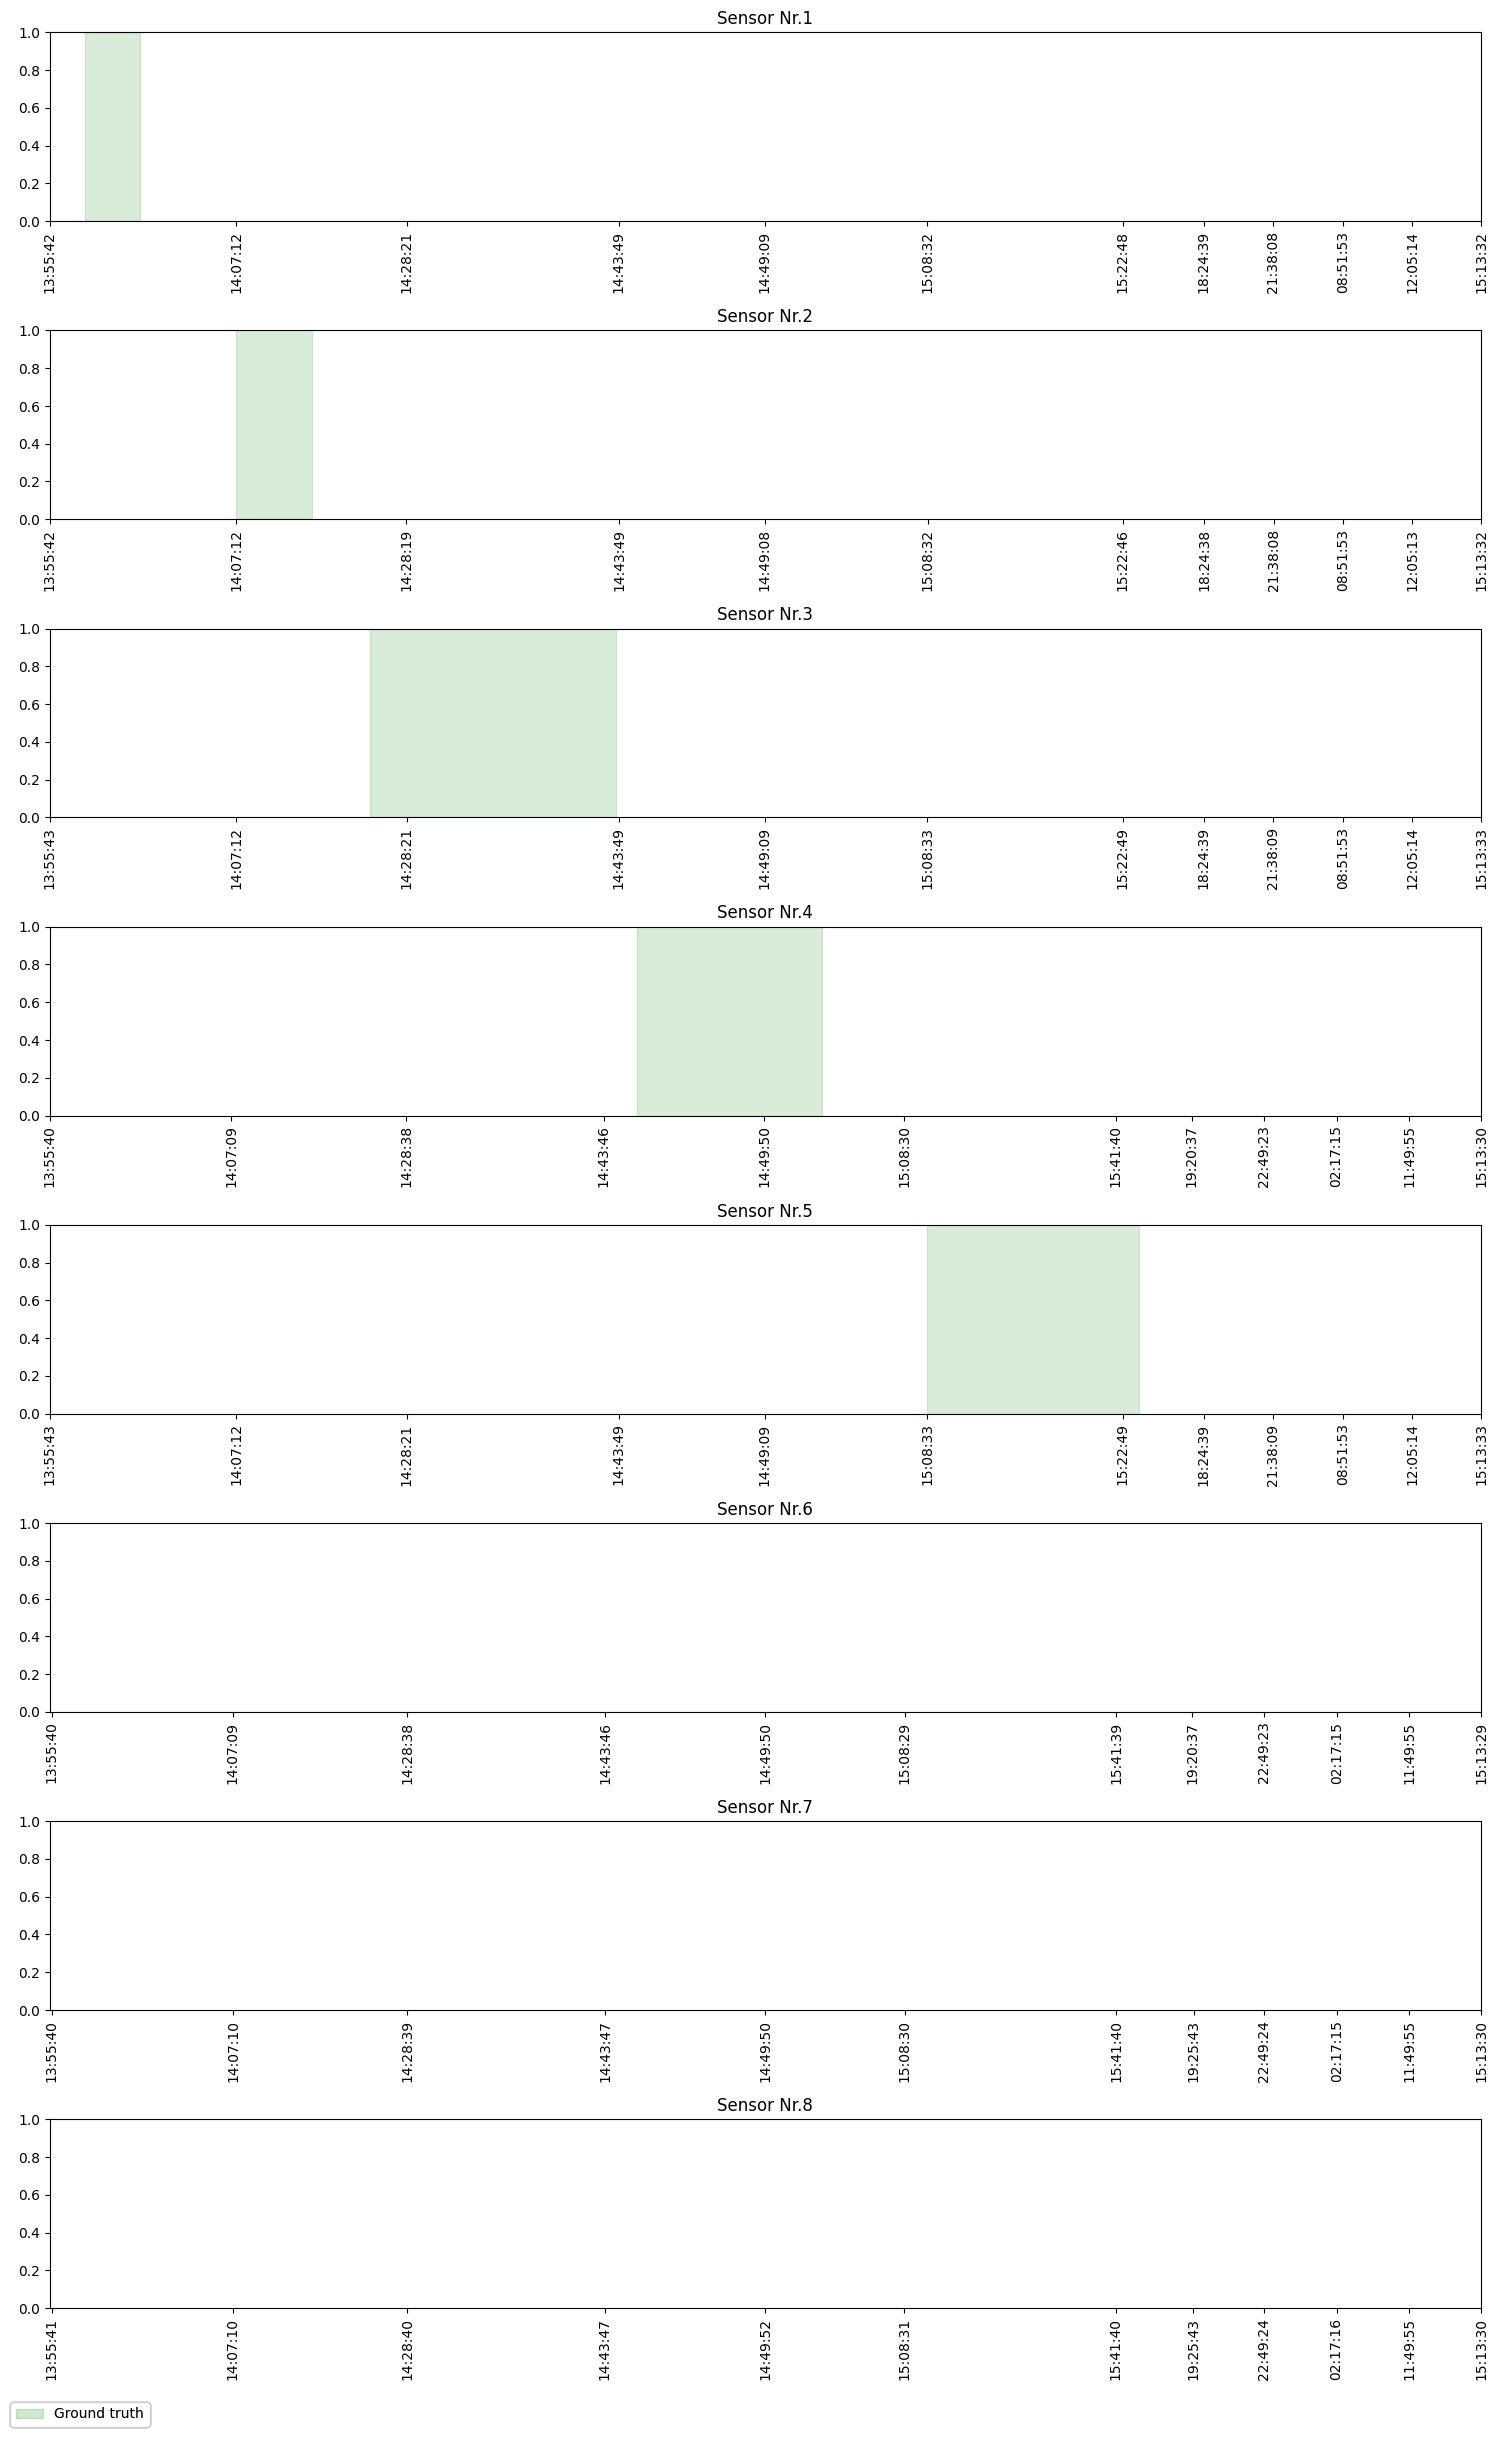

In [ ]:
fig, axs = plt.subplots(8, 1, sharey=True, figsize=(15, 8*3))
plt.tight_layout(h_pad=5.0)
for i, sensor in enumerate(data):\
    sensor["y"]
    
    
    ax = axs[i]
    ax.set_title(f"Sensor Nr.{i+1}") 
    print_ground_truth(ax, sensor, i)        

    format_time_xticks(ax, index=sensor["x"], num_ticks=5, rotation=90)
    create_legend(fig, *fig.axes)

# Speed of Flowfront

In [52]:
dstnc_betw_sens = [0, 5, 5, 2.5, 2.8] # cm
pos_sens = np.cumsum(dstnc_betw_sens)

 
-7.017e-05 x + 0.3534


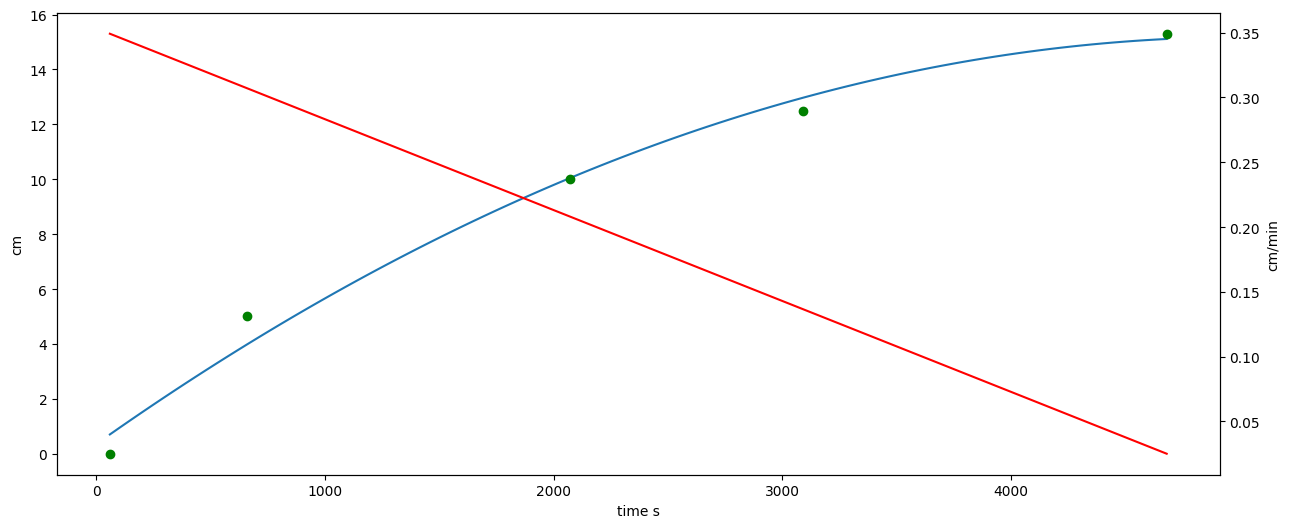

In [53]:
flwfnt_mid_sensor = [(int((((front+end) /2) - ground_truth_us[0][0])/1e6)) for (front, end) in ground_truth_us][:5]
poly_fun = np.poly1d(np.polyfit(flwfnt_mid_sensor, pos_sens, 2))
poly_x = np.linspace(flwfnt_mid_sensor[0], flwfnt_mid_sensor[-1], 100)
poly_y = poly_fun(poly_x)

speed_fun = poly_fun.deriv() * 60
speed_y = speed_fun(poly_x)

fig, ax = plt.subplots(figsize=(15, 6)) 
ax.set_xlabel("time s")
ax.set_ylabel("cm")
ax.plot(poly_x, poly_y)
ax2 = plt.twinx()
ax2.set_ylabel("cm/min")
ax2.plot(poly_x, speed_y, color="red")
for i in range(len(dstnc_betw_sens)):
    ax.plot(flwfnt_mid_sensor[i], pos_sens[i], "o", color="green")

print(speed_fun)

For cross-reference:
one segment between the red lines on the Peel-Ply is approx. 2,74cm wide.
30:43-47:03 for one segment at sensor 3 ->   2,74cm / 980sec = 0.178cm/min

# Curing